In [29]:
import numpy as np
from matplotlib import pyplot as plt
from dotenv import load_dotenv
import os

load_dotenv()

DATASET_ROOT = os.getenv("DATASET_ROOT")
RPG_MASK_SUBDIR = "rpg_masks_buffered_10m"#os.getenv("RPG_MASK_SUBDIR")
RPG_MASKS_PATH = os.path.join(DATASET_ROOT, RPG_MASK_SUBDIR)
INVERTED_RPG_MASKS_PATH = os.path.join(DATASET_ROOT, f"{RPG_MASK_SUBDIR}_inverted")

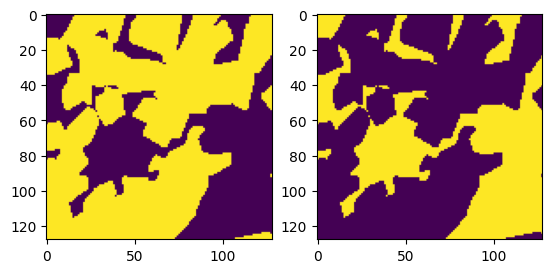

In [30]:
def invert_array(array: np.ndarray) -> np.ndarray:
    return -1 * (array - 1)

mask_paths = os.listdir(RPG_MASKS_PATH)

test_mask_path = os.path.join(RPG_MASKS_PATH, mask_paths[0])

def get_mask_and_inverted(mask_path):
    with open(mask_path, "rb+") as infile:
        mask = np.load(infile).astype(np.int64)
        mask_inverted = invert_array(mask)
    return mask, mask_inverted

test_mask, test_mask_inverted = get_mask_and_inverted(test_mask_path)

_, axs = plt.subplots(nrows=1, ncols=2)
axs[0].imshow(test_mask)
axs[1].imshow(test_mask_inverted)
plt.show()


In [33]:
np.sum(test_mask_inverted + test_mask) - (128 * 128)

np.int64(0)

In [34]:
for path in mask_paths:
    full_path = os.path.join(RPG_MASKS_PATH, path)
    _, mask_inverted = get_mask_and_inverted(full_path)

    with open(os.path.join(INVERTED_RPG_MASKS_PATH, path), "wb+") as outfile:
        np.save(outfile, mask_inverted)